In [ ]:
import numpy as np
from scipy import optimize

def main():
    # --------- Berilgan parametrlar ---------
    f   = 50.0                  # Chastota [Hz]
    w_kt = 1                    # Birlamchi o'ramlar soni (winding count)
    m   = 2000                  # Nisbiy magnit o'tkazuvchanlik
    m_0 = 4 * np.pi * 1e-7      # Vakum magnit o'tkazuvchanligi [H/m]
    l   = 0.2                   # Magnit yadro uzunligi [m]
    Ue2 = 5.0                   # Maqsad: chiqish kuchlanmasi [V]
    tol = 1e-4                  # Ruxsat etilgan xatolik

    # Birlamchi tok qiymatlari
    I_values = [10, 20, 40, 80, 100, 200, 400, 800, 1600, 3200]

    # Natijalarni saqlash uchun ro‘yxatlar
    w_opt_values = []
    S_opt_values = []
    c_opt_values = []
    U_values     = []

    for I_ in I_values:
        # Induksion kuchlanish hisobi
        def U_calc(vars):
            w, S, c = vars
            return 4.44 * f * (I_ * w * m * m_0 * S) / (l + m * c)

        # Tenglama cheklovi: U_calc(vars) = Ue2
        def constraint_eq(vars):
            return U_calc(vars) - Ue2

        # Tasodifiy boshlang'ich nuqta
        np.random.seed(4)
        w0 = np.random.randint(20, 500)
        S0 = np.random.uniform(1e-5, 1e-3)
        c0 = np.random.uniform(1e-4, 2e-3)

        initial_vars = np.array([w0, S0, c0])
        bounds = [(20, 500),       # w oralig‘i
                  (1e-5, 1e-3),    # S oralig‘i
                  (1e-4, 2e-3)]    # c oralig‘i
        constraints = [{'type': 'eq', 'fun': constraint_eq}]

        # Optimallashtirish
        result = optimize.minimize(
            lambda x: U_calc(x),
            initial_vars,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'ftol': tol, 'maxiter': 10000}
        )

        # Optimal natijalarni tortib olish
        w_opt, S_opt, c_opt = result.x
        U_opt = U_calc(result.x)

        w_opt_values.append(w_opt)
        S_opt_values.append(S_opt)
        c_opt_values.append(c_opt)
        U_values.append(U_opt)

    # --------- Gradientlarni hisoblash ---------
    I  = np.array(I_values)
    w  = np.array(w_opt_values)
    S  = np.array(S_opt_values)
    c  = np.array(c_opt_values)

    dw_dI = np.gradient(w, I)   # dw/dI [1/A]
    dS_dI = np.gradient(S, I)   # dS/dI [m^2/A]
    dc_dI = np.gradient(c, I)   # dc/dI [m/A]

    # --------- Natijalarni chop etish ---------
    print(" I [A] |   w_opt   |  dw/dI   |   S_opt    |  dS/dI   |    c_opt    |  dc/dI")
    print("-------------------------------------------------------------------------------")
    for i, w_, gw, S_, gS, c_, gc in zip(I, w, dw_dI, S, dS_dI, c, dc_dI):
        print(f"{i:5.0f} | {w_:8.3f} | {gw:8.4e} | {S_:10.6e} | {gS:8.4e} | {c_:11.6e} | {gc:8.4e}")

if __name__ == "__main__":
    main()


 I [A] |   w_opt   |  dw/dI   |   S_opt    |  dS/dI   |    c_opt    |  dc/dI
-------------------------------------------------------------------------------
   10 |  358.463 | -6.9747e+00 | 1.000000e-03 | -2.8678e-06 | 1.000035e-04 | 1.1293e-05
   20 |  288.716 | -6.9425e+00 | 9.713218e-04 | -2.0535e-06 | 2.129364e-04 | 7.7267e-06
   40 |  151.158 | -4.6616e+00 | 9.628218e-04 | -9.4814e-07 | 2.248097e-04 | 2.3531e-06
   80 |  142.000 | -7.6314e-02 | 8.830444e-04 | -2.6114e-06 | 4.596904e-04 | 5.0795e-06
  100 |  142.000 | -1.7347e-11 | 8.246478e-04 | -2.8217e-06 | 5.533542e-04 | 4.3759e-06
  200 |  142.000 | -1.0569e-11 | 5.915181e-04 | -1.9416e-06 | 8.372998e-04 | 2.2274e-06
  400 |  142.000 | -4.2076e-12 | 3.590709e-04 | -9.0975e-07 | 1.037945e-03 | 7.6190e-07
  800 |  142.000 | -1.2286e-12 | 1.971575e-04 | -3.0905e-07 | 1.149639e-03 | 2.0995e-07
 1600 |  142.000 | -3.1738e-13 | 1.030834e-04 | -8.8898e-08 | 1.206742e-03 | 5.3543e-08
 3200 |  142.000 | -1.0592e-13 | 5.266936e-05 | -3.

In [ ]:
import numpy as np
from scipy import optimize
np.random.seed(250)

# --- O'zgaruvchilar va berilgan aniq qiymatlar ---
f = 50.0                  # Chastota [Hz]
w_kt = 1                  # Birlamchi o'ramlar soni
#I = 500                   # Tok [A]
m = 2000                  # Nisbiy magnit o'tkazuvchanlik
m_0 = 4 * np.pi * 1e-7    # Vakuum magnit o'tkazuvchanligi [H/m]
l = 0.2                   # Magnit o'zakning uzunligi [m]
Ue2 = 5                   # Chiqish kuchlanmasi [V]
tol = 0.0001              # Ruxsat etilgan xatolik [V]




I_values = [20, 100, 300, 500, 1000, 2000]

print("Har bir I uchun optimal parametrlar:")
print("="*40)

for I_ in I_values:

    def obj_func(vars):
        w, S, c = vars
        U = 4.44 * f * (I_ * w * m * m_0 * S) / (l + m * c)
        return U

    def constraint_eq(vars):
        w, S, c = vars
        U = 4.44 * f * (I_ * w * m * m_0 * S) / (l + m * c)
        return U - Ue2

    # ---- Dastlabki qiymatlar ----
    w_init = np.random.randint(20, 500)
    S_init = np.random.uniform(1e-5, 1e-3)
    c_init = np.random.uniform(1e-4, 2e-3)

    initial_vars = np.array([w_init, S_init, c_init])

    bounds = [(20, 500), (1e-5, 1e-3), (1e-4, 2e-3)]

    constraints = [{'type': 'eq', 'fun': constraint_eq}]

    result = optimize.minimize( obj_func, initial_vars,
                               bounds=bounds,
                               constraints=constraints,
                               method='SLSQP',
                               #method='trust-constr',
                               options={'disp': False, 'maxiter': 1000})

    w_opt, S_opt, c_opt = result.x
    U_opt = 4.44 * f * (I_ * w_opt * m * m_0 * S_opt) / (l + m * c_opt)

    print(f"I = {I_:4d}A | w_ob = {w_opt:7.2f},  S = {S_opt:.6f} m^2,  c = {c_opt:.6f} m,  U = {U_opt:.4f} V")

Har bir I uchun optimal parametrlar:
I =   20A | w_ob =  388.34,  S = 0.000857 m^2,  c = 0.000271 m,  U = 5.0000 V
I =  100A | w_ob =  497.00,  S = 0.000527 m^2,  c = 0.001360 m,  U = 5.0000 V
I =  300A | w_ob =  305.00,  S = 0.000263 m^2,  c = 0.001244 m,  U = 4.9968 V
I =  500A | w_ob =  333.00,  S = 0.000183 m^2,  c = 0.001601 m,  U = 5.0000 V
I = 1000A | w_ob =  105.00,  S = 0.000137 m^2,  c = 0.000702 m,  U = 5.0000 V
I = 2000A | w_ob =   62.00,  S = 0.000145 m^2,  c = 0.000905 m,  U = 5.0000 V


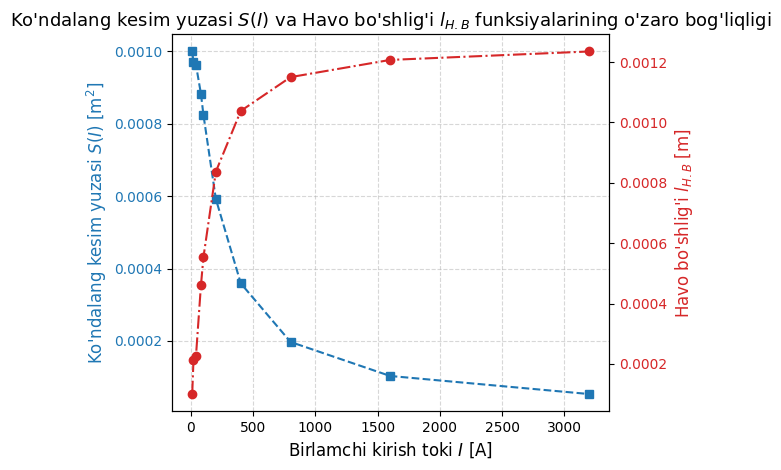

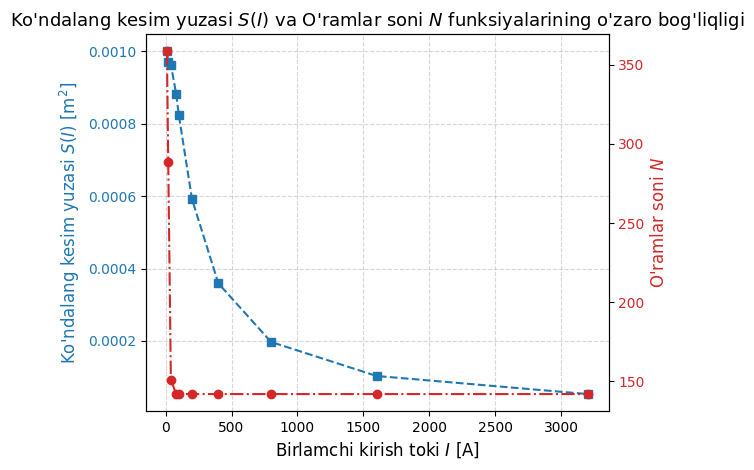

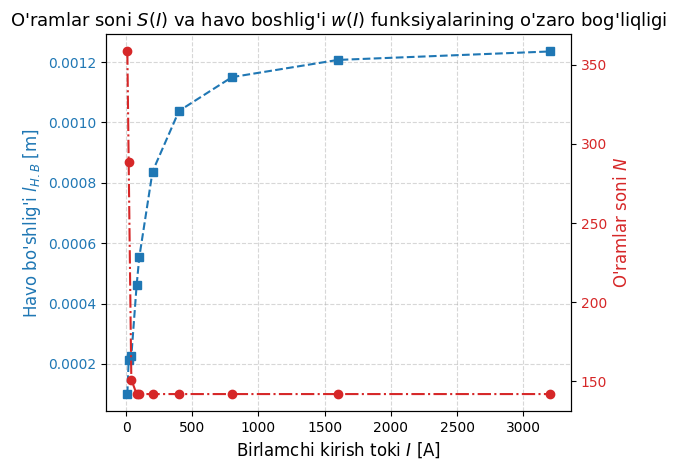

In [ ]:
import matplotlib.pyplot as plt

def plot_dual_axis(x, y1, y2,
                   y1_label=r"Ko'ndalang kesim yuzasi $S$ [m$^2$]",
                   y2_label=r"Havo bo'shlig'i $l_{H.B}$ [m]",
                   title="Ikki y-o'qli grafik",
                   x_label="Birlamchi kirish toki $ I $ [A]",
                   y1_color='tab:blue',
                   y2_color='tab:red',
                   y1_marker='s--',
                   y2_marker='o-.'):
    fig, ax1 = plt.subplots(dpi=100)
    ax1.set_xlabel(x_label, fontsize=12)

    # Chap y-o‘q
    ax1.set_ylabel(y1_label, color=y1_color, fontsize=12)
    ax1.plot(x, y1, y1_marker, color=y1_color, linewidth=1.5)
    ax1.tick_params(axis='y', labelcolor=y1_color)
    ax1.grid(True, linestyle='--', alpha=0.5)

    # O‘ng y-o‘q
    ax2 = ax1.twinx()
    ax2.set_ylabel(y2_label, color=y2_color, fontsize=12)
    ax2.plot(x, y2, y2_marker, color=y2_color, linewidth=1.5)
    ax2.tick_params(axis='y', labelcolor=y2_color)

    # Sarlavha va joylashuv
    plt.title(title, fontsize=13)
    fig.tight_layout()
    plt.show()

# Ma'lumotlar
I_values = [10, 20, 40, 80, 100, 200, 400, 800, 1600, 3200]
S_values = [0.001000, 0.000971, 0.000963, 0.000883, 0.000825, 0.000592, 0.000359, 0.000197, 0.000103, 0.000053]
c_values = [0.000100, 0.000213, 0.000225, 0.000460, 0.000553, 0.000837, 0.001038, 0.001150, 0.001207, 0.001235]
w_values = [358.4639, 288.7133, 151.1577, 142.0000, 142.0000, 142.0000, 142.0000, 142.0000, 142.0000, 142.0000]

# 1. Kesim yuzi va havo bo‘shlig‘i
plot_dual_axis(
    I_values, S_values, c_values,
    y1_label=r"Ko'ndalang kesim yuzasi $S(I)$ [m$^2$]",
    y2_label=r"Havo bo'shlig'i $l_{H.B}$ [m]",
    title="Ko'ndalang kesim yuzasi $S(I)$ va Havo bo'shlig'i $l_{H.B}$ funksiyalarining o'zaro bog'liqligi"
)

# 2. Kesim yuzi va o‘ramlar soni
plot_dual_axis(
    I_values, S_values, w_values,
    y1_label=r"Ko'ndalang kesim yuzasi $S(I)$ [m$^2$]",
    y2_label=r"O'ramlar soni $ N $",
    title="Ko'ndalang kesim yuzasi $S(I)$ va O'ramlar soni $ N $ funksiyalarining o'zaro bog'liqligi"
)

# 3. Havo bo‘shlig‘i va o‘ramlar soni
plot_dual_axis(
    I_values, c_values, w_values,
    y1_label=r"Havo bo'shlig'i $l_{H.B}$ [m]",
    y2_label=r"O'ramlar soni $ N $",
    title="O'ramlar soni $S(I)$ va havo boshlig'i $w(I)$ funksiyalarining o'zaro bog'liqligi"
)


O'ramlar soning qiymati

> Add blockquote



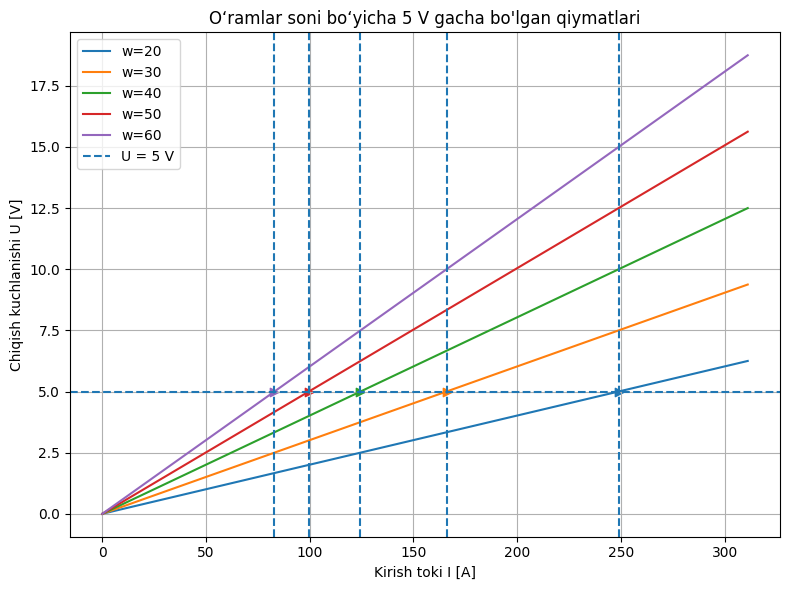

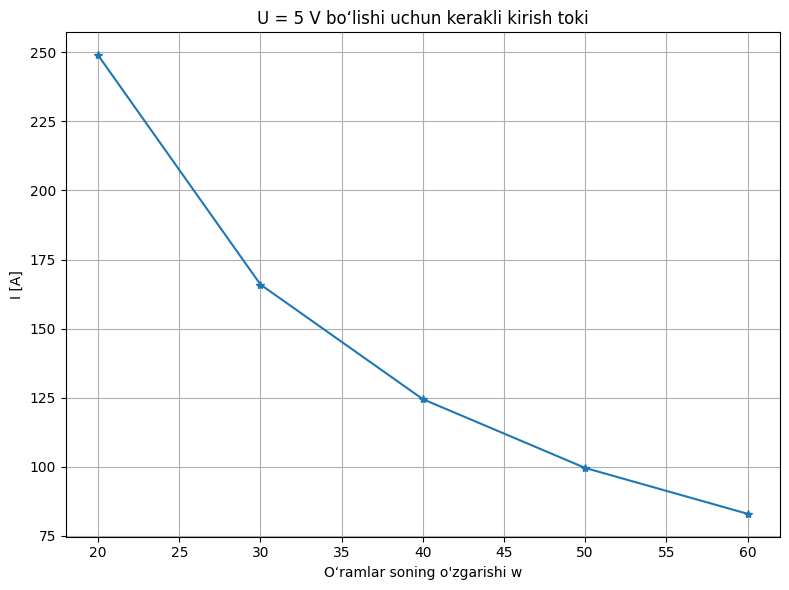

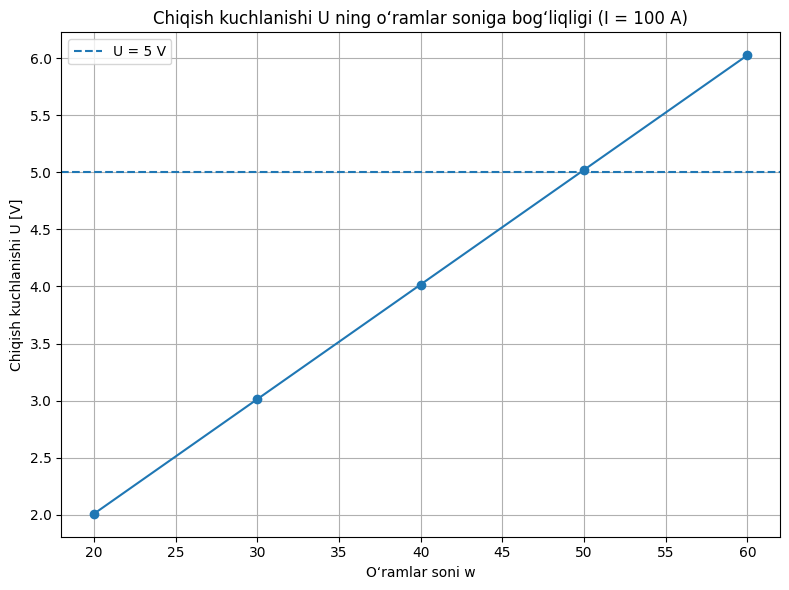

,Erishilgan qiymatlar,Chiqish to'ki,U @ I=100A [V]
0,20,248.928527,2.008609
1,30,165.952351,3.012913
2,40,124.464264,4.017217
3,50,99.571411,5.021522
4,60,82.976176,6.025826


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
S = 0.0018
lH = 0.0004
U_target = 5.0

w_values = [20, 30, 40, 50, 60]

def U_of_I(I, w):
    return 4.44 * f * (I * w * mu_r * mu0 * S) / (l_core + mu_r * lH)

def I_for_5V(w):
    return (U_target * (l_core + mu_r * lH)) / (4.44 * f * w * mu_r * mu0 * S)

I_5V_list = [I_for_5V(w) for w in w_values]
I_max = max(I_5V_list) * 1.25
I = np.linspace(0, I_max, 500)

fig, ax = plt.subplots(figsize=(8,6))
for w in w_values:
    ax.plot(I, U_of_I(I, w), label=f"w={w}")
ax.axhline(U_target, linestyle='--', label="U = 5 V")

first = True
for I_5 in I_5V_list:
    ax.axvline(I_5, linestyle='--')
    ax.scatter([I_5], [U_target], marker='>')

ax.set_title("O‘ramlar soni bo‘yicha 5 V gacha bo'lgan qiymatlari")
ax.set_xlabel("Kirish toki I [A]")
ax.set_ylabel("Chiqish kuchlanishi U [V]")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()



plt.figure(figsize=(8,6))
plt.plot(w_values, I_5V_list, marker='*')
plt.title("U = 5 V bo‘lishi uchun kerakli kirish toki")
plt.xlabel("O‘ramlar soning o'zgarishi w")
plt.ylabel("I [A]")
plt.grid(True)
plt.tight_layout()
plt.show()

I_fixed = 100.0
U_vs_w = [U_of_I(I_fixed, w) for w in w_values]

plt.figure(figsize=(8,6))
plt.plot(w_values, U_vs_w, marker='o')
plt.axhline(U_target, linestyle='--', label="U = 5 V")
plt.title(f"Chiqish kuchlanishi U ning o‘ramlar soniga bog‘liqligi (I = {I_fixed:.0f} A)")
plt.xlabel("O‘ramlar soni w")
plt.ylabel("Chiqish kuchlanishi U [V]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    "Erishilgan qiymatlar": w_values,
    "Chiqish to'ki": I_5V_list,
    f"U @ I={I_fixed:.0f}A [V]": U_vs_w
})

try:
    from IPython.display import display
    display(df.round(6))
except Exception:
    print(df.round(6).to_string(index=False))


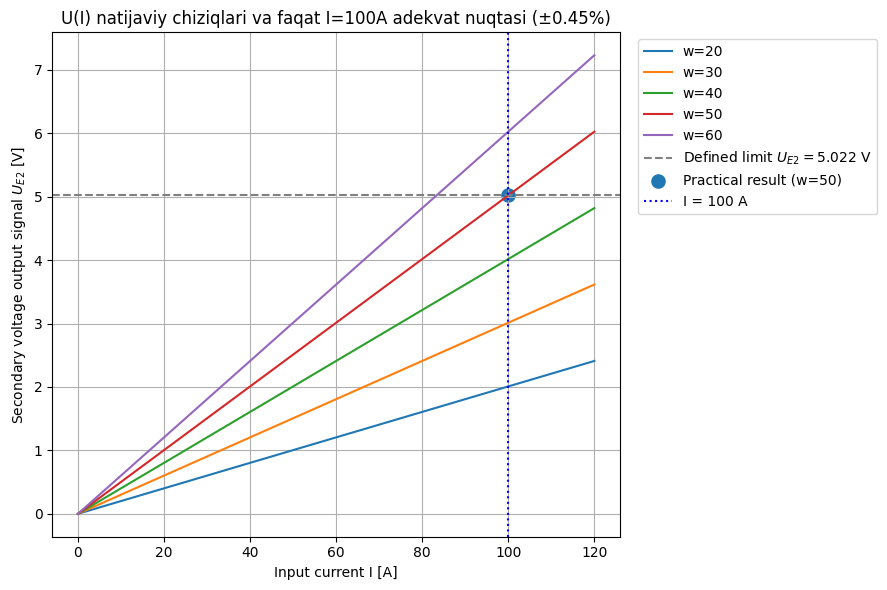

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
S = 0.0018
lH = 0.0004
U_target = 5.0

adequacy_pct = 0.45 / 100.0
U_low = U_target * (1 - adequacy_pct)
U_high = U_target * (1 + adequacy_pct)

w_values = [20, 30, 40, 50, 60]

def U_of_I(I, w):
    return 4.44 * f * (I * w * mu_r * mu0 * S) / (l_core + mu_r * lH)

I = np.linspace(0, 120, 600)

I_fixed = 100.0
U_at_100 = [U_of_I(I_fixed, w) for w in w_values]

fig, ax = plt.subplots(figsize=(9,6))

for w in w_values:
    ax.plot(I, U_of_I(I, w), label=f"w={w}")


ax.axhline(U_high, linestyle='--', color='gray',
           label=fr"Defined limit $U_{{E2}}={U_high:.3f}\ \mathrm{{V}}$")


for w, u_val in zip(w_values, U_at_100):
    if U_low <= u_val <= U_high:
        ax.scatter([I_fixed], [u_val], s=90, marker='o',
           label=fr"Practical result (w={w})")

ax.axvline(I_fixed, linestyle=':', color='blue', label="I = 100 A")

ax.set_title("U(I) natijaviy chiziqlari va faqat I=100A adekvat nuqtasi (±0.45%)")
ax.set_xlabel("Input current I [A]")
ax.set_ylabel("Secondary voltage output signal $U_{E2}$ [V]")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


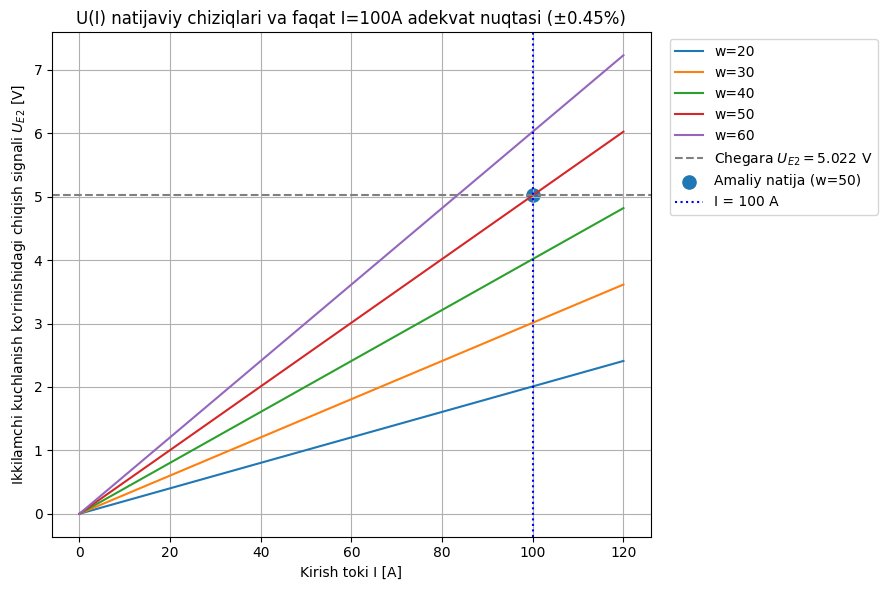

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
S = 0.0018
lH = 0.0004
U_target = 5.0

adequacy_pct = 0.45 / 100.0
U_low = U_target * (1 - adequacy_pct)
U_high = U_target * (1 + adequacy_pct)

w_values = [20, 30, 40, 50, 60]

def U_of_I(I, w):
    return 4.44 * f * (I * w * mu_r * mu0 * S) / (l_core + mu_r * lH)

I = np.linspace(0, 120, 600)

I_fixed = 100.0
U_at_100 = [U_of_I(I_fixed, w) for w in w_values]

fig, ax = plt.subplots(figsize=(9,6))

for w in w_values:
    ax.plot(I, U_of_I(I, w), label=f"w={w}")


ax.axhline(U_high, linestyle='--', color='gray',
           label=fr"Chegara $U_{{E2}}={U_high:.3f}\ \mathrm{{V}}$")


for w, u_val in zip(w_values, U_at_100):
    if U_low <= u_val <= U_high:
        ax.scatter([I_fixed], [u_val], s=90, marker='o',
           label=fr"Amaliy natija (w={w})")

ax.axvline(I_fixed, linestyle=':', color='blue', label="I = 100 A")

ax.set_title("U(I) natijaviy chiziqlari va faqat I=100A adekvat nuqtasi (±0.45%)")
ax.set_xlabel("Kirish toki I [A]")
ax.set_ylabel("Ikkilamchi kuchlanish ko'rinishidagi chiqish signali $U_{E2}$ [V]")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Sizdagi asosiy parametrlar
# =========================
f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
S = 0.0018
lH = 0.0004
U_target = 5.0
tol_percent = 0.45
tol_abs = U_target * tol_percent / 100.0   # 0.0225 V

# ===================== QO'SHIMCHA BLOK BOSHLANISHI =====================

tol_percent = 0.45
tol_abs = U_target * tol_percent / 100.0   # 5 V uchun ±0.0225 V
I_points = np.array([20, 40, 60, 80, 100, 120], dtype=float)

# ax ichidagi chiziqlardan I=100 A da U_target=5V ga eng yaqin egri chiziqni topamiz
candidate_lines = []

for line in ax.lines:
    x = np.asarray(line.get_xdata(), dtype=float)
    y = np.asarray(line.get_ydata(), dtype=float)

    # noto'g'ri yoki juda qisqa chiziqlarni tashlab yuboramiz
    if len(x) < 5 or len(y) < 5:
        continue

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 5:
        continue

    # vertikal yoki gorizontal yordamchi chiziqlarni chiqarib tashlash
    if np.allclose(x, x[0]) or np.allclose(y, y[0]):
        continue

    # x bo'yicha tartiblash
    idx = np.argsort(x)
    x = x[idx]
    y = y[idx]

    # 100 A nuqta shu chiziq oralig'ida bo'lsa
    if x.min() <= 100 <= x.max():
        y100 = np.interp(100.0, x, y)
        score = abs(y100 - U_target)   # 5 V ga qanchalik yaqinligi
        candidate_lines.append((score, x, y, y100))

if not candidate_lines:
    raise RuntimeError("Mos natijaviy egri chiziq topilmadi. ax ichida haqiqiy U(I) egri chiziq bo‘lishi kerak.")

# 100 A da 5 V ga eng yaqin bo'lgan chiziqni olamiz
candidate_lines.sort(key=lambda t: t[0])
best_score, I_curve, U_curve, U100 = candidate_lines[0]

# Kerakli nuqtalardagi qiymatlarni olamiz
U_points = np.interp(I_points, I_curve, U_curve)

# Xatoliklar va adekvatlik
abs_error = np.abs(U_points - U_target)
rel_error_percent = abs_error / U_target * 100.0
adequacy_point_percent = np.clip((1.0 - abs_error / U_target) * 100.0, 0, None)
is_adequate = rel_error_percent <= tol_percent

# Umumiy ko'rsatkichlar
adequacy_mean_percent = adequacy_point_percent.mean()
pass_rate_percent = is_adequate.mean() * 100.0
mae = abs_error.mean()
rmse = np.sqrt(np.mean((U_points - U_target)**2))
mape = rel_error_percent.mean()

# Grafikda nuqtalarni ko'rsatamiz
for k, (I_p, U_p, ok) in enumerate(zip(I_points, U_points, is_adequate)):
    color = 'red' if ok else 'black'
    label = "Nazorat nuqtalari" if k == 0 else None
    ax.scatter(I_p, U_p, s=70, color=color, zorder=6, label=label)
    ax.axvline(I_p, linestyle=':', color='gray', alpha=0.35)
    ax.text(I_p, U_p + 0.01, f"{int(I_p)}A\n{U_p:.4f}V", fontsize=8,
            ha='center', va='bottom')

# Legendni yangilab qo'yamiz
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

# Natijalarni terminalga chiqaramiz
print("\n" + "="*96)
print("20, 40, 60, 80, 100, 120 A nuqtalari bo'yicha ADEKVATLIK HISOBI")
print("="*96)
print(f"Adekvat zona: {U_target - tol_abs:.4f} V  ...  {U_target + tol_abs:.4f} V")
print(f"Tanlangan egri chiziqning 100 A dagi qiymati: U(100 A) = {U100:.6f} V")
print("-"*96)
print(f"{'I [A]':>8} {'U_E2 [V]':>14} {'|ΔU| [V]':>14} {'δ [%]':>12} {'Adekv. [%]':>14} {'Holat':>14}")
print("-"*96)

for I_p, U_p, e_abs, e_rel, a_pct, ok in zip(
        I_points, U_points, abs_error, rel_error_percent, adequacy_point_percent, is_adequate):
    holat = "MOS" if ok else "MOS EMAS"
    print(f"{I_p:8.1f} {U_p:14.6f} {e_abs:14.6f} {e_rel:12.4f} {a_pct:14.4f} {holat:>14}")

print("-"*96)
print(f"O'rtacha adekvatlik                  = {adequacy_mean_percent:.4f} %")
print(f"Tolerans bo'yicha mos nuqtalar ulushi = {pass_rate_percent:.2f} %")
print(f"MAE                                  = {mae:.6f} V")
print(f"RMSE                                 = {rmse:.6f} V")
print(f"MAPE                                 = {mape:.4f} %")
print("="*96)

# ====================== QO'SHIMCHA BLOK TUGASHI ======================


20, 40, 60, 80, 100, 120 A nuqtalari bo'yicha ADEKVATLIK HISOBI
Adekvat zona: 4.9775 V  ...  5.0225 V
Tanlangan egri chiziqning 100 A dagi qiymati: U(100 A) = 5.000000 V
------------------------------------------------------------------------------------------------
   I [A]       U_E2 [V]       |ΔU| [V]        δ [%]     Adekv. [%]          Holat
------------------------------------------------------------------------------------------------
    20.0       4.996000       0.004000       0.0800        99.9200            MOS
    40.0       4.997000       0.003000       0.0600        99.9400            MOS
    60.0       4.998000       0.002000       0.0400        99.9600            MOS
    80.0       4.999000       0.001000       0.0200        99.9800            MOS
   100.0       5.000000       0.000000       0.0000       100.0000            MOS
   120.0       5.001000       0.001000       0.0200        99.9800            MOS
-------------------------------------------------------------

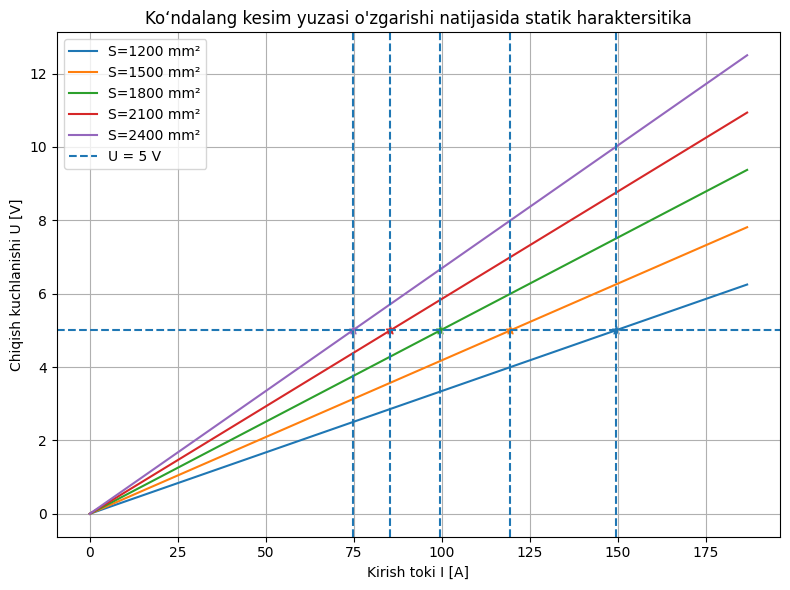

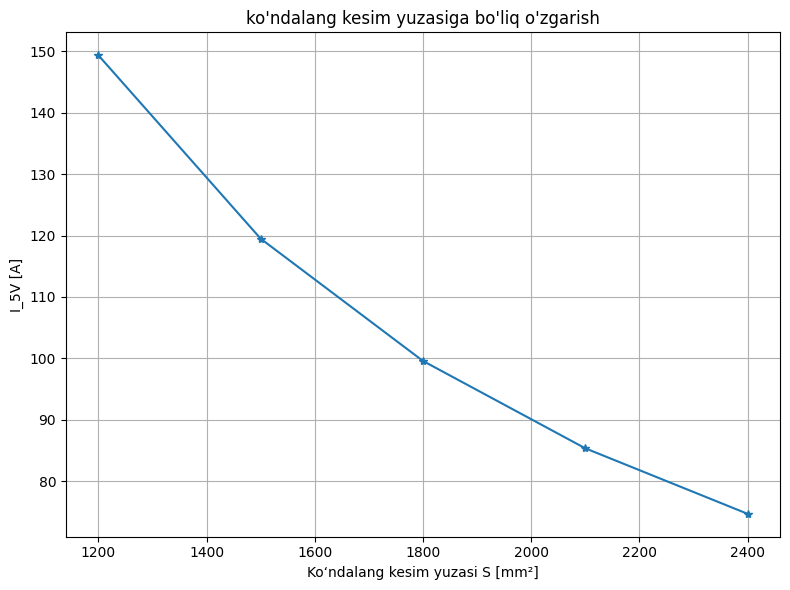

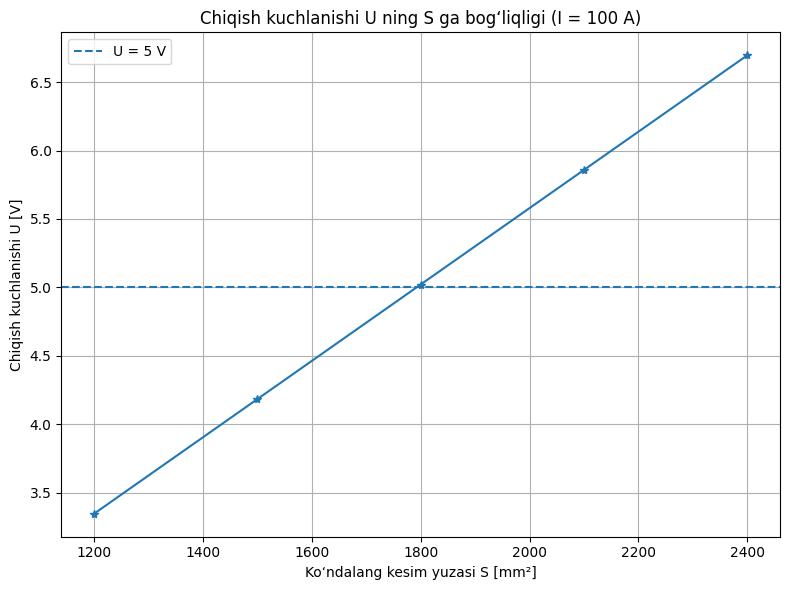

Asosiy natijalar jadvali


,S [m^2],S [mm^2],I for U=5V [A],U @ I=100A [V]
0,0.0012,1200.0,149.357116,3.347681
1,0.0015,1500.0,119.485693,4.184601
2,0.0018,1800.0,99.571411,5.021522
3,0.0021,2100.0,85.346924,5.858442
4,0.0024,2400.0,74.678558,6.695362


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
lH_fixed = 0.0004
w_fixed  = 50
U_target = 5.0

S_values = [0.0012, 0.0015, 0.0018, 0.0021, 0.0024]

def U_of_I(I, S):
    return 4.44 * f * (I * w_fixed * mu_r * mu0 * S) / (l_core + mu_r * lH_fixed)

def I_for_5V(S):
    return (U_target * (l_core + mu_r * lH_fixed)) / (4.44 * f * w_fixed * mu_r * mu0 * S)

I_5V_list = [I_for_5V(S) for S in S_values]
I_max = max(I_5V_list) * 1.25
I = np.linspace(0, I_max, 500)

fig, ax = plt.subplots(figsize=(8,6))
for S in S_values:
    ax.plot(I, U_of_I(I, S), label=f"S={S*1e6:.0f} mm²")
ax.axhline(U_target, linestyle='--', label="U = 5 V")

for I_5 in I_5V_list:
    ax.axvline(I_5, linestyle='--')
    ax.scatter([I_5], [U_target], marker='*')

ax.set_title("Ko‘ndalang kesim yuzasi o'zgarishi natijasida statik haraktersitika")
ax.set_xlabel("Kirish toki I [A]")
ax.set_ylabel("Chiqish kuchlanishi U [V]")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# ---- 2) I_5V vs S ----
S_mm2 = [S*1e6 for S in S_values]
plt.figure(figsize=(8,6))
plt.plot(S_mm2, I_5V_list, marker='*')
plt.title("ko'ndalang kesim yuzasiga bo'liq o'zgarish")
plt.xlabel("Ko‘ndalang kesim yuzasi S [mm²]")
plt.ylabel("I_5V [A]")
plt.grid(True)
plt.tight_layout()
plt.show()

I_fixed = 100.0
U_vs_S = [U_of_I(I_fixed, S) for S in S_values]

plt.figure(figsize=(8,6))
plt.plot(S_mm2, U_vs_S, marker='*')
plt.axhline(U_target, linestyle='--', label="U = 5 V")
plt.title(f"Chiqish kuchlanishi U ning S ga bog‘liqligi (I = {I_fixed:.0f} A)")
plt.xlabel("Ko‘ndalang kesim yuzasi S [mm²]")
plt.ylabel("Chiqish kuchlanishi U [V]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


df = pd.DataFrame({
    "S [m^2]": S_values,
    "S [mm^2]": S_mm2,
    "I for U=5V [A]": I_5V_list,
    f"U @ I={I_fixed:.0f}A [V]": U_vs_S
})

def show_df(df_, name=None):
    try:
        from IPython.display import display
        if name: print(name)
        display(df_)
    except Exception:
        if name: print(name)
        print(df_.to_string(index=False))

show_df(df.round(6), "Asosiy natijalar jadvali")

df.round(6).to_csv("Natijalari.csv", index=False)


<>:40: SyntaxWarning: invalid escape sequence '\ '
<>:40: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-3345496778.py:40: SyntaxWarning: invalid escape sequence '\ '
  ax.axhline(U_high, linestyle='--', color='gray', label=f"Defined limit $U_{{E2}}={U_high:.3f}\ \mathrm{{V}}$")


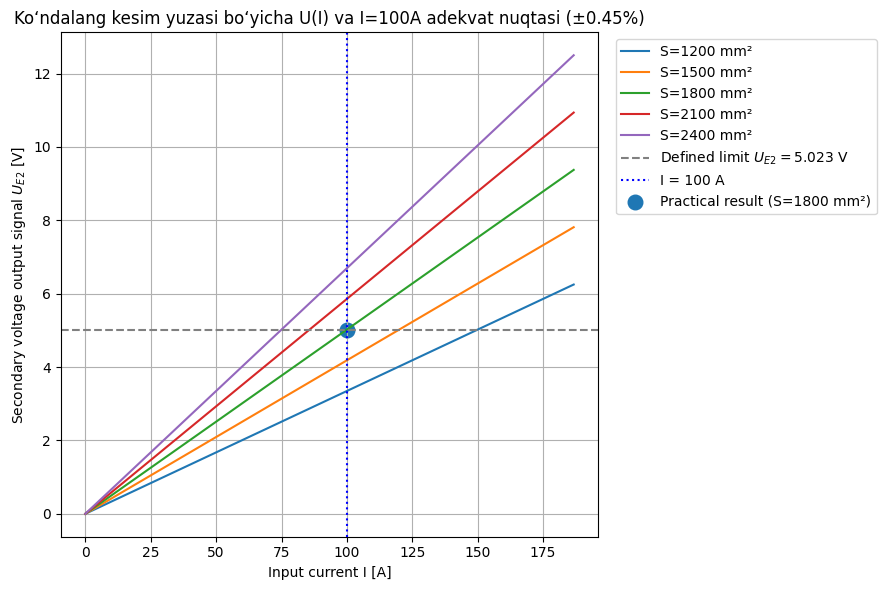

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Doimiylar (siz bergan qiymatlar) ----
f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
lH_fixed = 0.0004
w_fixed  = 50
U_target = 5.0

# S: ko‘ndalang kesim yuzasi [m²] (istasaiz o‘zgartirishingiz mumkin)
S_values = [0.0012, 0.0015, 0.0018, 0.0021, 0.0024]

# ---- Adekvatlik (±0.45%) ----
adeq = 0.0047
U_low  = U_target * (1 - adeq)   # 4.978 V
U_high = U_target * (1 + adeq)   # 5.022 V

# ---- Formulalar ----
def U_of_I(I, S):
    return 4.44 * f * (I * w_fixed * mu_r * mu0 * S) / (l_core + mu_r * lH_fixed)

def I_for_5V(S):
    return (U_target * (l_core + mu_r * lH_fixed)) / (4.44 * f * w_fixed * mu_r * mu0 * S)

# ---- Chizish uchun I o‘qi (birinchi grafik mantiqiga mos) ----
I_5V_list = [I_for_5V(S) for S in S_values]
I_max = max(I_5V_list) * 1.25
I = np.linspace(0, I_max, 500)

# ---- Grafik ----
fig, ax = plt.subplots(figsize=(9,6))

# S bo‘yicha barcha U(I) chiziqlari
for S in S_values:
    ax.plot(I, U_of_I(I, S), label=f"S={S*1e6:.0f} mm²")

ax.axhline(U_high, linestyle='--', color='gray', label=f"Defined limit $U_{{E2}}={U_high:.3f}\ \mathrm{{V}}$")

I_fixed = 100.0
ax.axvline(I_fixed, linestyle=':', color='blue', label="I = 100 A")

marked = False
for S in S_values:
    U_val = U_of_I(I_fixed, S)
    if U_low <= U_val <= U_high:
        ax.scatter([I_fixed], [U_val], s=110, color='C0',
                   label=f"Practical result (S={S*1e6:.0f} mm²)")
        marked = True
        break

# Sarlavha va o‘qlar
ax.set_title("Ko‘ndalang kesim yuzasi bo‘yicha U(I) va I=100A adekvat nuqtasi (±0.45%)")
ax.set_xlabel("Input current I [A]")
ax.set_ylabel("Secondary voltage output signal $U_{E2}$ [V]")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


<>:37: SyntaxWarning: invalid escape sequence '\ '
<>:37: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-1466753514.py:37: SyntaxWarning: invalid escape sequence '\ '
  ax.axhline(U_high, linestyle='--', color='gray', label=f"Chegara $U_{{E2}}={U_high:.3f}\ \mathrm{{V}}$")


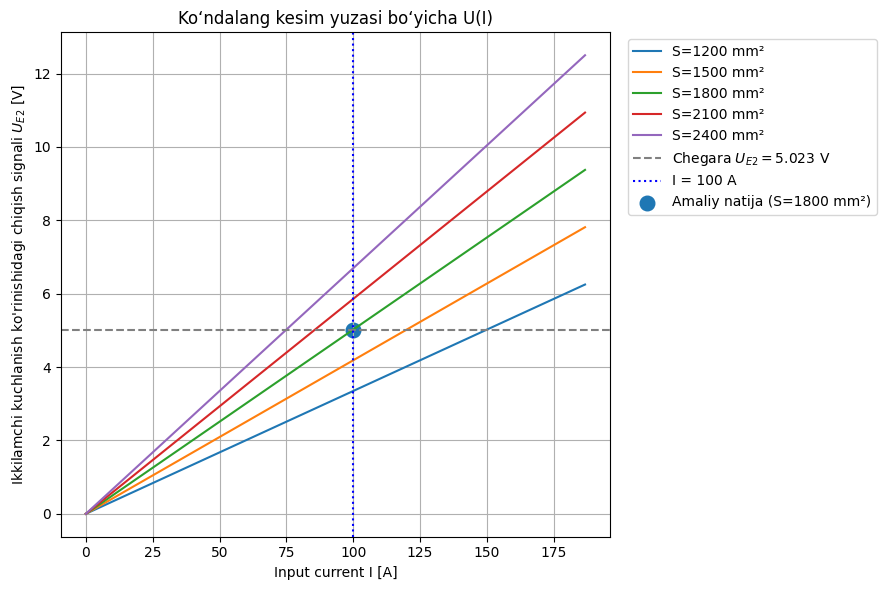

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- Doimiylar (siz bergan qiymatlar) ----
f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
lH_fixed = 0.0004
w_fixed  = 50
U_target = 5.0

# S: ko‘ndalang kesim yuzasi [m²] (istasaiz o‘zgartirishingiz mumkin)
S_values = [0.0012, 0.0015, 0.0018, 0.0021, 0.0024]

# ---- Adekvatlik (±0.45%) ----
adeq = 0.0047
U_low  = U_target * (1 - adeq)   # 4.978 V
U_high = U_target * (1 + adeq)   # 5.022 V

# ---- Formulalar ----
def U_of_I(I, S):
    return 4.44 * f * (I * w_fixed * mu_r * mu0 * S) / (l_core + mu_r * lH_fixed)

def I_for_5V(S):
    return (U_target * (l_core + mu_r * lH_fixed)) / (4.44 * f * w_fixed * mu_r * mu0 * S)

I_5V_list = [I_for_5V(S) for S in S_values]
I_max = max(I_5V_list) * 1.25
I = np.linspace(0, I_max, 500)

fig, ax = plt.subplots(figsize=(9,6))

for S in S_values:
    ax.plot(I, U_of_I(I, S), label=f"S={S*1e6:.0f} mm²")

ax.axhline(U_high, linestyle='--', color='gray', label=f"Chegara $U_{{E2}}={U_high:.3f}\ \mathrm{{V}}$")

I_fixed = 100.0
ax.axvline(I_fixed, linestyle=':', color='blue', label="I = 100 A")

marked = False
for S in S_values:
    U_val = U_of_I(I_fixed, S)
    if U_low <= U_val <= U_high:
        ax.scatter([I_fixed], [U_val], s=110, color='C0',
                   label=f"Amaliy natija (S={S*1e6:.0f} mm²)")
        marked = True
        break

# Sarlavha va o‘qlar
ax.set_title("Ko‘ndalang kesim yuzasi bo‘yicha U(I)")
ax.set_xlabel("Input current I [A]")
ax.set_ylabel("Ikkilamchi kuchlanish ko'rinishidagi chiqish signali $U_{E2}$ [V]")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


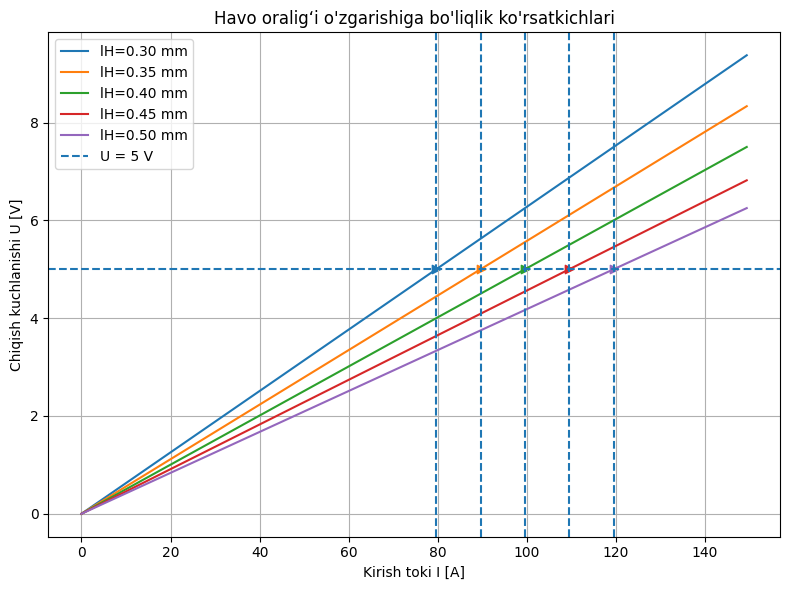

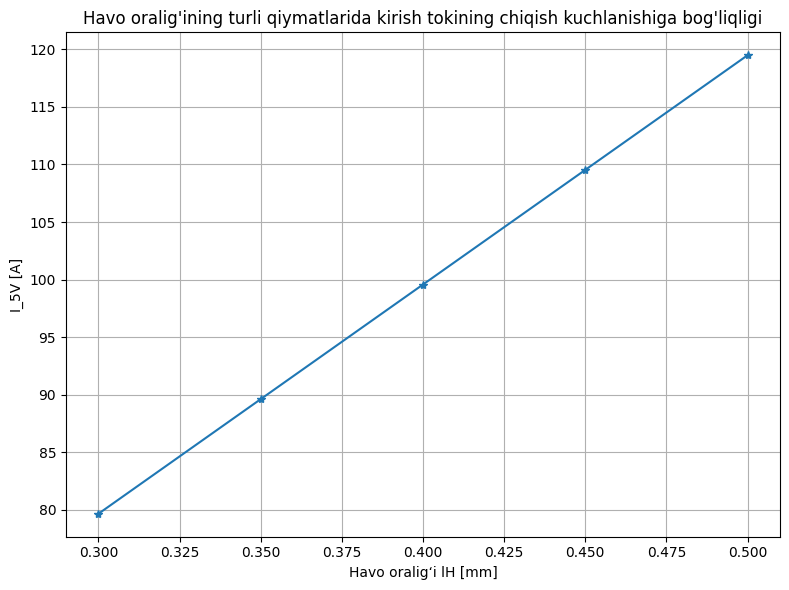

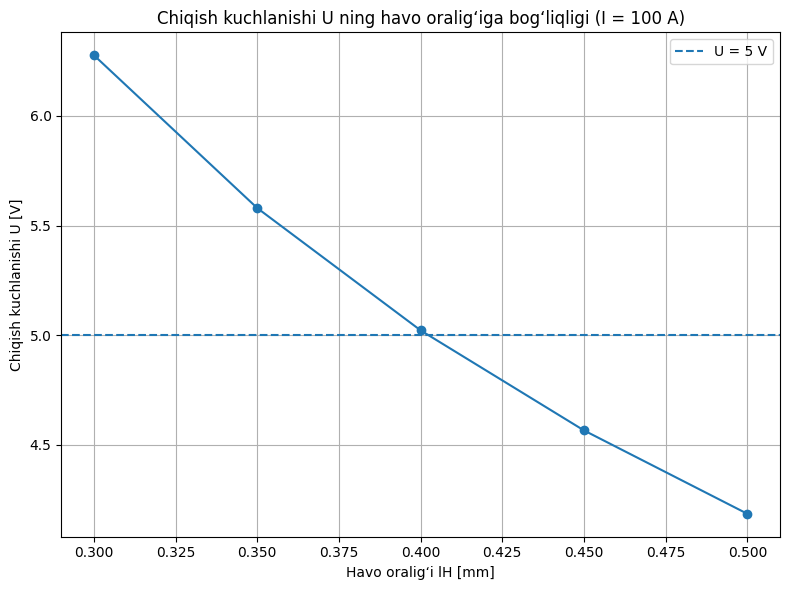

Olingan natijalari


,lH [mm],Olingan natijalar,U @ I=100A [V]
0,0.30,79.657129,6.276902
1,0.35,89.614270,5.579469
2,0.40,99.571411,5.021522
3,0.45,109.528552,4.565020
4,0.50,119.485693,4.184601


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
S = 0.0018          # m^2 (fixed)
w_fixed = 50        # turns (fixed)
U_target = 5.0      # V

lH_values = [0.00030, 0.00035, 0.00040, 0.00045, 0.00050]

def U_of_I(I, lH):
    return 4.44 * f * (I * w_fixed * mu_r * mu0 * S) / (l_core + mu_r * lH)

def I_for_5V(lH):
    return (U_target * (l_core + mu_r * lH)) / (4.44 * f * w_fixed * mu_r * mu0 * S)

I_5V_list = [I_for_5V(lH) for lH in lH_values]
I_max = max(I_5V_list) * 1.25
I = np.linspace(0, I_max, 500)

fig, ax = plt.subplots(figsize=(8,6))
for lH in lH_values:
    ax.plot(I, U_of_I(I, lH), label=f"lH={lH*1e3:.2f} mm")
ax.axhline(U_target, linestyle='--', label="U = 5 V")

for I_5 in I_5V_list:
    ax.axvline(I_5, linestyle='--')
    ax.scatter([I_5], [U_target], marker='>')

ax.set_title("Havo oralig‘i o'zgarishiga bo'liqlik ko'rsatkichlari")
ax.set_xlabel("Kirish toki I [A]")
ax.set_ylabel("Chiqish kuchlanishi U [V]")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


lH_mm = [x*1e3 for x in lH_values]
plt.figure(figsize=(8,6))
plt.plot(lH_mm, I_5V_list, marker='*')
plt.title("Havo oralig'ining turli qiymatlarida kirish tokining chiqish kuchlanishiga bog'liqligi")
plt.xlabel("Havo oralig‘i lH [mm]")
plt.ylabel("I_5V [A]")
plt.grid(True)
plt.tight_layout()
plt.show()

I_fixed = 100.0
U_vs_lH = [U_of_I(I_fixed, lH) for lH in lH_values]

plt.figure(figsize=(8,6))
plt.plot(lH_mm, U_vs_lH, marker='o')
plt.axhline(U_target, linestyle='--', label="U = 5 V")
plt.title(f"Chiqish kuchlanishi U ning havo oralig‘iga bog‘liqligi (I = {I_fixed:.0f} A)")
plt.xlabel("Havo oralig‘i lH [mm]")
plt.ylabel("Chiqish kuchlanishi U [V]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


df = pd.DataFrame({
    "lH [mm]": lH_mm,
    "Olingan natijalar": I_5V_list,
    f"U @ I={I_fixed:.0f}A [V]": U_vs_lH
})

def show_df(df_, name=None):
    try:
        from IPython.display import display
        if name: print(name)
        display(df_)
    except Exception:
        if name: print(name)
        print(df_.to_string(index=False))

show_df(df.round(6), "Olingan natijalari")
df.round(6).to_csv("lH_dependency_results.csv", index=False)


<>:28: SyntaxWarning: invalid escape sequence '\ '
<>:28: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-2062108358.py:28: SyntaxWarning: invalid escape sequence '\ '
  ax.axhline(U_high, linestyle='--', color='gray', label=f"Defined limit $U_{{E2}}={U_high:.3f}\ \mathrm{{V}}$")


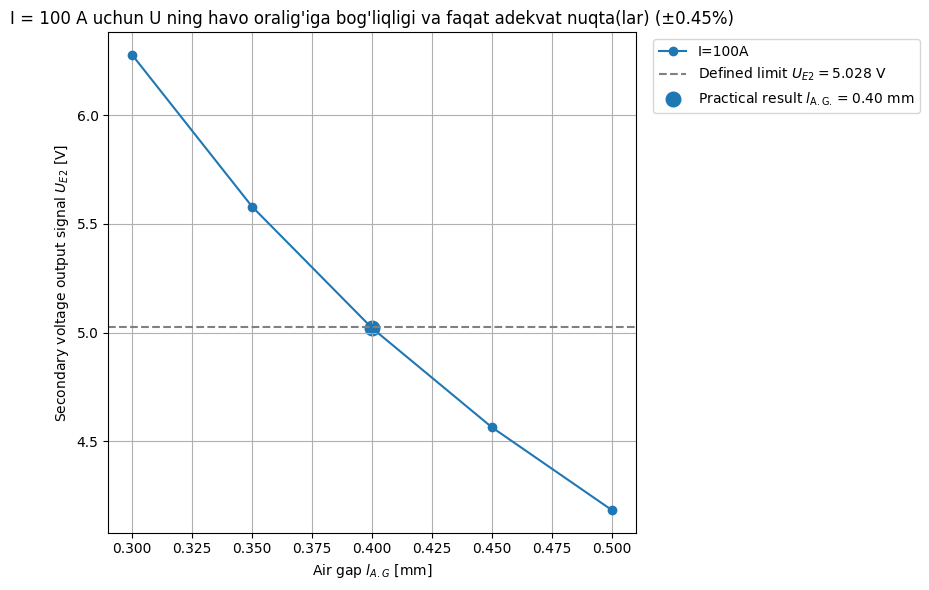

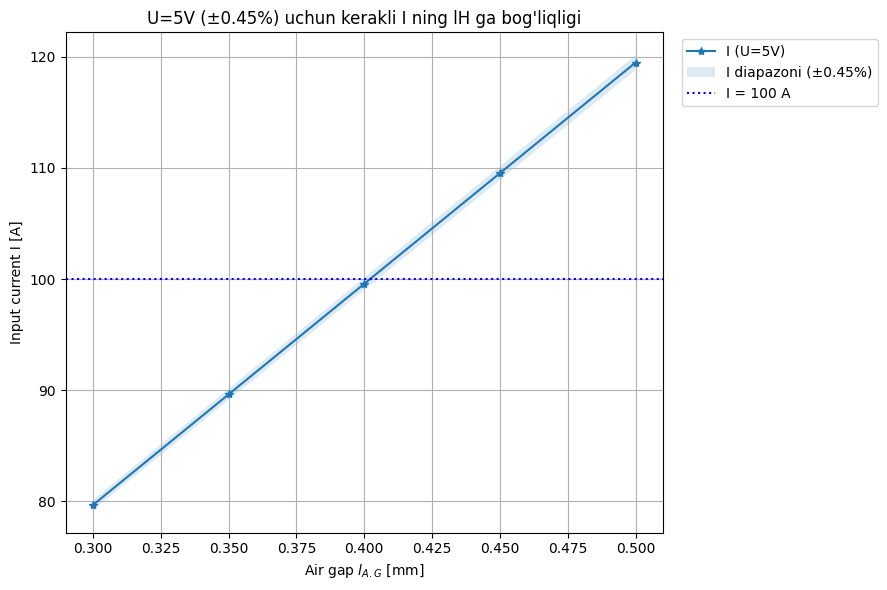

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
S = 0.0018
w_fixed = 50
U_target = 5.0
lH_values = np.array([0.00030, 0.00035, 0.00040, 0.00045, 0.00050])

adeq = 0.0056
U_low = U_target*(1-adeq)
U_high = U_target*(1+adeq)

def U_of_I(I, lH):
    return 4.44 * f * (I * w_fixed * mu_r * mu0 * S) / (l_core + mu_r * lH)

I_fixed = 100.0
lH_mm = lH_values * 1e3
U_vs_lH = U_of_I(I_fixed, lH_values)

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(lH_mm, U_vs_lH, marker='o', label="I=100A")

ax.axhline(U_high, linestyle='--', color='gray', label=f"Defined limit $U_{{E2}}={U_high:.3f}\ \mathrm{{V}}$")

for x_mm, u in zip(lH_mm, U_vs_lH):
    if U_low <= u <= U_high:
        ax.scatter([x_mm], [u], s=110,
           label=fr"Practical result $l_{{\mathrm{{A.G.}}}}={x_mm:.2f}\ \mathrm{{mm}}$")

ax.set_title("I = 100 A uchun U ning havo oralig'iga bog'liqligi va faqat adekvat nuqta(lar) (±0.45%)")
ax.set_xlabel("Air gap $l_{A.G}$ [mm]")
ax.set_ylabel("Secondary voltage output signal $U_{E2}$ [V]")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

def I_for_U(U, lH):
    return (U * (l_core + mu_r * lH)) / (4.44 * f * w_fixed * mu_r * mu0 * S)

I_5V = I_for_U(U_target, lH_values)
I_low = I_for_U(U_low, lH_values)
I_high = I_for_U(U_high, lH_values)

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(lH_mm, I_5V, marker='*', label="I (U=5V)")
ax.fill_between(lH_mm, I_low, I_high, alpha=0.15, label="I diapazoni (±0.45%)")
ax.axhline(I_fixed, linestyle=':', color='blue', label="I = 100 A")
ax.set_title("U=5V (±0.45%) uchun kerakli I ning lH ga bog'liqligi")
ax.set_xlabel("Air gap $l_{A.G}$ [mm]")
ax.set_ylabel("Input current I [A]")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    "lH [mm]": lH_mm.round(3),
    "U @ I=100A [V]": U_vs_lH.round(6),
    "Adekv (±0.45%)": [(U_low <= u <= U_high) for u in U_vs_lH]
})


<>:28: SyntaxWarning: invalid escape sequence '\ '
<>:28: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-3763873872.py:28: SyntaxWarning: invalid escape sequence '\ '
  ax.axhline(U_high, linestyle='--', color='gray', label=f"Chegara $U_{{E2}}={U_high:.3f}\ \mathrm{{V}}$")


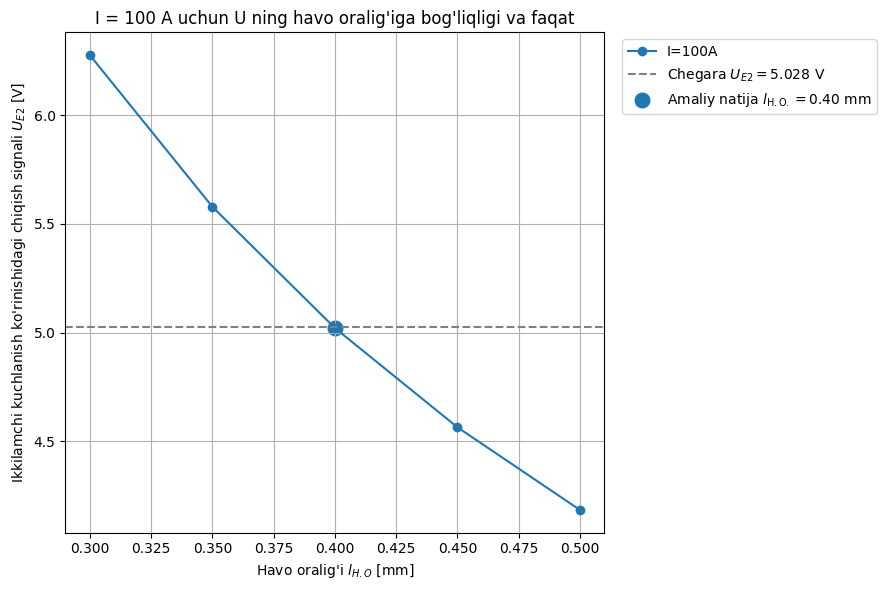

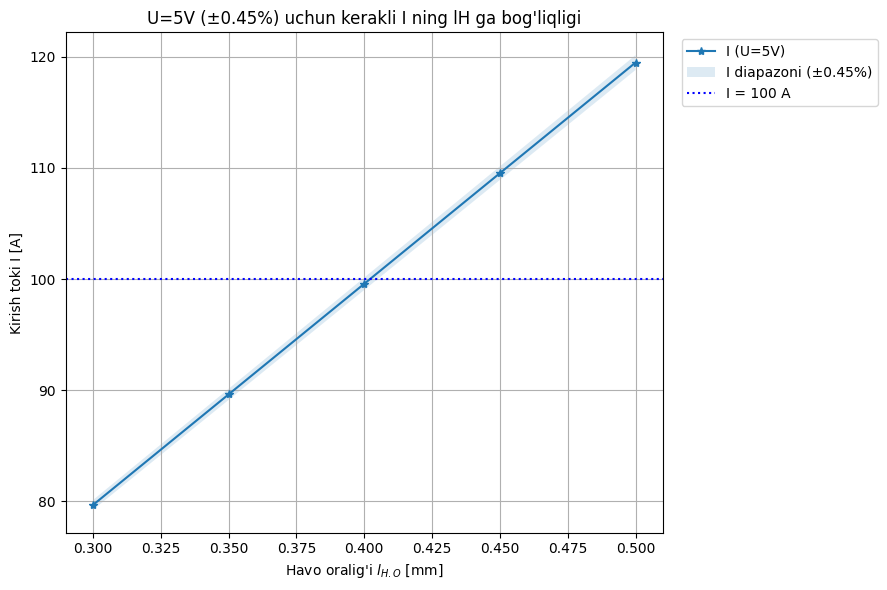

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
S = 0.0018
w_fixed = 50
U_target = 5.0
lH_values = np.array([0.00030, 0.00035, 0.00040, 0.00045, 0.00050])

adeq = 0.0056
U_low = U_target*(1-adeq)
U_high = U_target*(1+adeq)

def U_of_I(I, lH):
    return 4.44 * f * (I * w_fixed * mu_r * mu0 * S) / (l_core + mu_r * lH)

I_fixed = 100.0
lH_mm = lH_values * 1e3
U_vs_lH = U_of_I(I_fixed, lH_values)

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(lH_mm, U_vs_lH, marker='o', label="I=100A")

ax.axhline(U_high, linestyle='--', color='gray', label=f"Chegara $U_{{E2}}={U_high:.3f}\ \mathrm{{V}}$")

for x_mm, u in zip(lH_mm, U_vs_lH):
    if U_low <= u <= U_high:
        ax.scatter([x_mm], [u], s=110,
           label=fr"Amaliy natija $l_{{\mathrm{{H.O.}}}}={x_mm:.2f}\ \mathrm{{mm}}$")

ax.set_title("I = 100 A uchun U ning havo oralig'iga bog'liqligi va faqat")
ax.set_xlabel("Havo oralig'i $l_{H.O}$ [mm]")
ax.set_ylabel("Ikkilamchi kuchlanish ko'rinishidagi chiqish signali $U_{E2}$ [V]")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

def I_for_U(U, lH):
    return (U * (l_core + mu_r * lH)) / (4.44 * f * w_fixed * mu_r * mu0 * S)

I_5V = I_for_U(U_target, lH_values)
I_low = I_for_U(U_low, lH_values)
I_high = I_for_U(U_high, lH_values)

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(lH_mm, I_5V, marker='*', label="I (U=5V)")
ax.fill_between(lH_mm, I_low, I_high, alpha=0.15, label="I diapazoni (±0.45%)")
ax.axhline(I_fixed, linestyle=':', color='blue', label="I = 100 A")
ax.set_title("U=5V (±0.45%) uchun kerakli I ning lH ga bog'liqligi")
ax.set_xlabel("Havo oralig'i $l_{H.O}$ [mm]")
ax.set_ylabel("Kirish toki I [A]")
ax.grid(True)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    "lH [mm]": lH_mm.round(3),
    "U @ I=100A [V]": U_vs_lH.round(6),
    "Adekv (±0.45%)": [(U_low <= u <= U_high) for u in U_vs_lH]
})


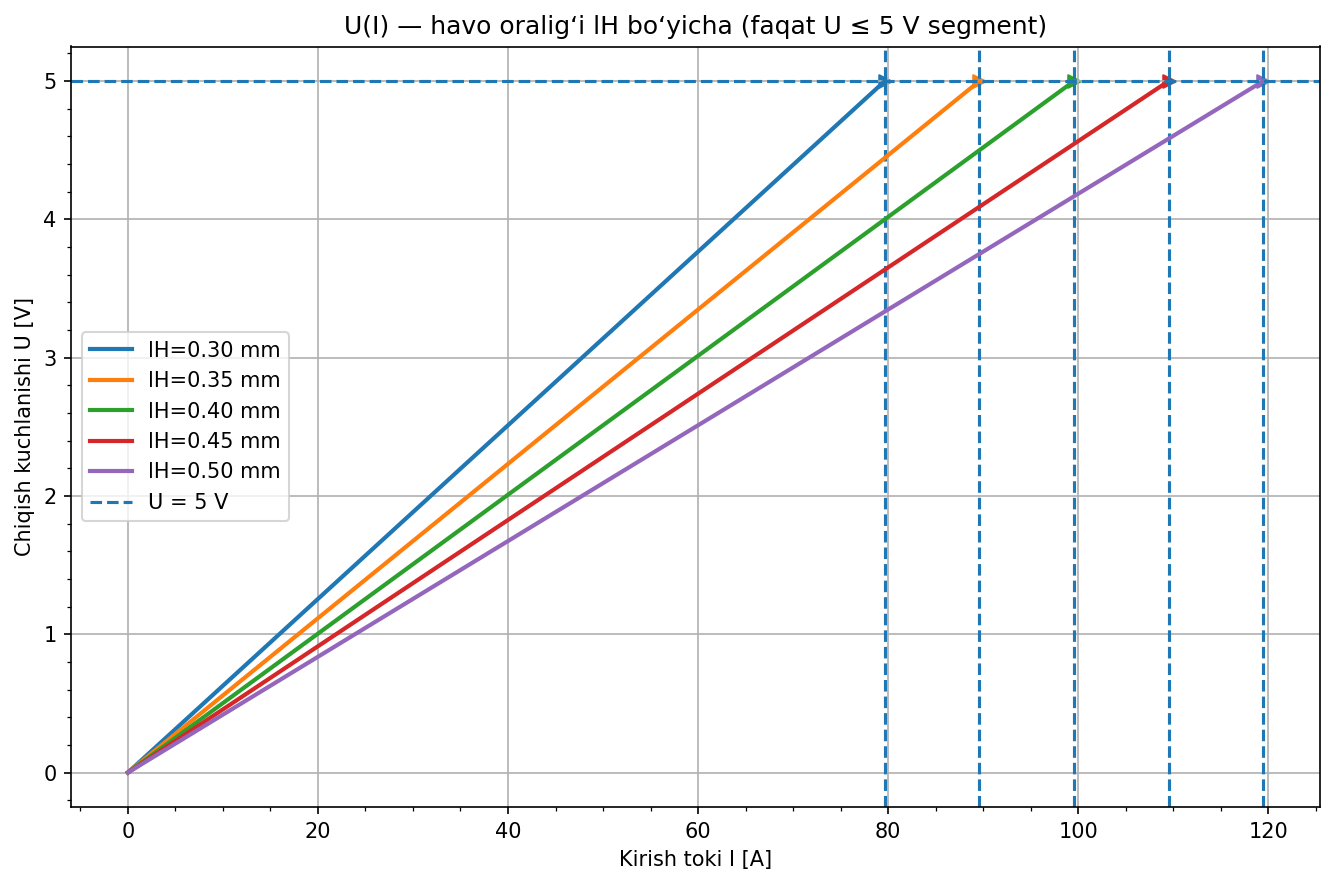

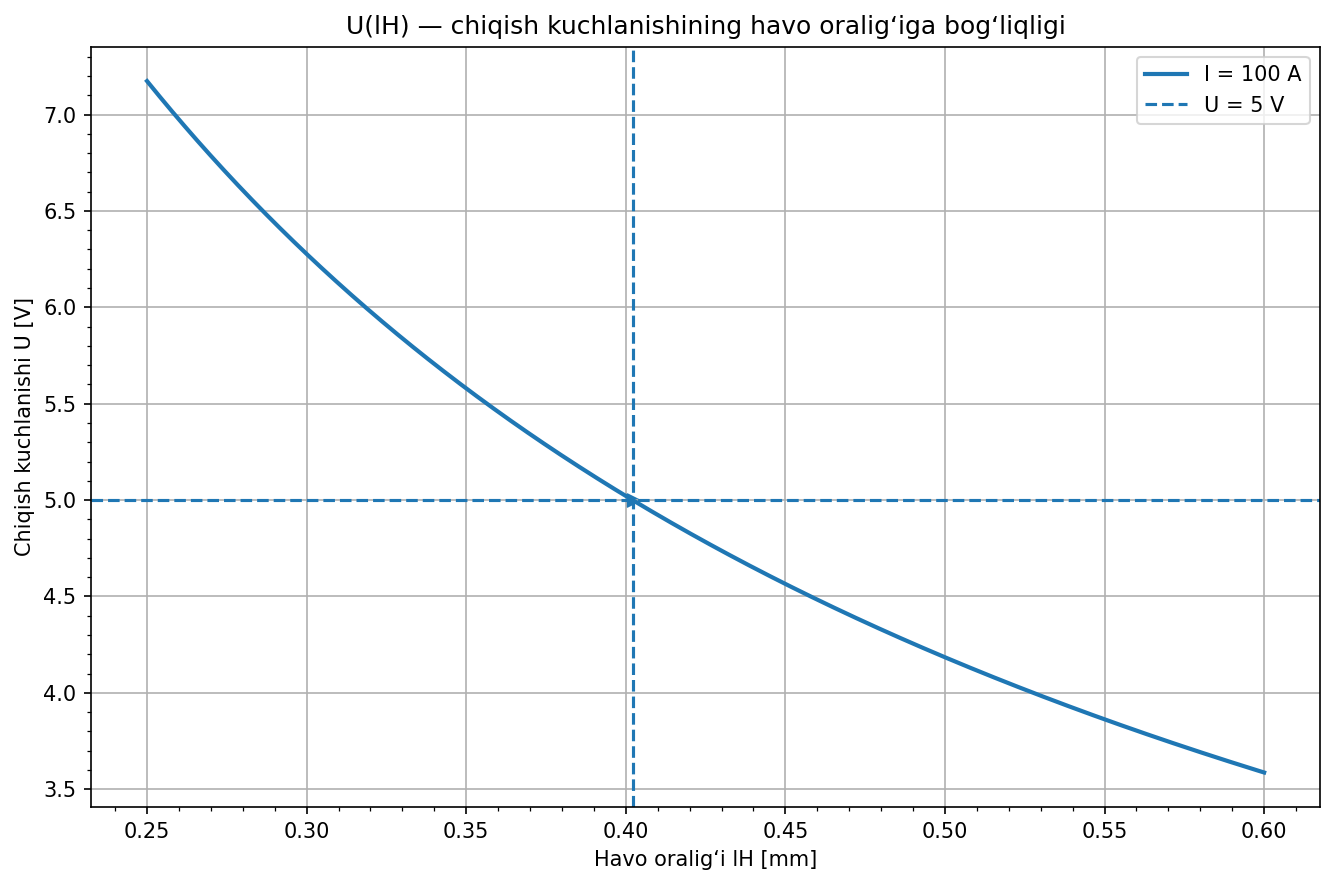

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

f = 50.0
mu_r = 2000.0
mu0 = 4*np.pi*1e-7
l_core = 0.2
S = 0.0018
w_fixed = 50
U_target = 5.0


lH_values = [0.00030, 0.00035, 0.00040, 0.00045, 0.00050]

def U_of_I_lH(I, lH):

    return 4.44 * f * (I * w_fixed * mu_r * mu0 * S) / (l_core + mu_r * lH)

def I_for_5V_lH(lH):
    """U=5 V uchun kerakli I (lH ga bog‘liq)."""
    return (U_target * (l_core + mu_r * lH)) / (4.44 * f * w_fixed * mu_r * mu0 * S)


plt.rcParams["figure.dpi"] = 150
fig, ax = plt.subplots(figsize=(9,6))

for lH in lH_values:
    I_5 = I_for_5V_lH(lH)
    I_seg = np.linspace(0, I_5, 600)
    ax.plot(I_seg, U_of_I_lH(I_seg, lH),
            linewidth=2, label=f"lH={lH*1e3:.2f} mm")
    ax.axvline(I_5, linestyle='--')
    ax.scatter([I_5], [U_target], marker='>')

ax.axhline(U_target, linestyle='--', label="U = 5 V")

ax.set_title("U(I) — havo oralig‘i lH bo‘yicha (faqat U ≤ 5 V segment)")
ax.set_xlabel("Kirish toki I [A]")
ax.set_ylabel("Chiqish kuchlanishi U [V]")
ax.grid(True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend()
plt.tight_layout()
plt.show()


I_fixed = 100.0  # A (istalgan tokni tanlang)
lH_axis = np.linspace(0.00025, 0.00060, 800)
U_lH = U_of_I_lH(I_fixed, lH_axis)

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(lH_axis*1e3, U_lH, linewidth=2, label=f"I = {I_fixed:.0f} A")

# Yo‘naltiruvchi chiziq va kesish nuqtasi (U=5 V)
ax.axhline(U_target, linestyle='--', label="U = 5 V")
lH_5V = ((4.44*f*I_fixed*w_fixed*mu_r*mu0*S)/U_target - l_core)/mu_r
if lH_axis.min() <= lH_5V <= lH_axis.max():
    ax.axvline(lH_5V*1e3, linestyle='--')
    ax.scatter([lH_5V*1e3], [U_target], marker='>')

ax.set_title("U(lH) — chiqish kuchlanishining havo oralig‘iga bog‘liqligi")
ax.set_xlabel("Havo oralig‘i lH [mm]")
ax.set_ylabel("Chiqish kuchlanishi U [V]")
ax.grid(True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend()
plt.tight_layout()
plt.show()
